Optimal number of cluster will be recognized. Moreover, charts for clustering metrics are drawn.

In [ ]:
from notebook_utils import cd2parent
cd2parent()

In [11]:
import os
import pandas as pd
import numpy as np


from scipy.optimize import curve_fit
from matplotlib import pyplot as plt

# from src.paths import DIR_COMP, DIR_DATA, DIR_CORES
from src.dataloader import Dataloader

In [12]:
dataloader = Dataloader()
dataloader.load_scores_selected()

In [13]:
scores = dataloader.scores_selected.set_index('smiles')
scores

,PC1,PC2,PC3
smiles,,,
C1NCC12CNO2,-0.876002,3.120620,-2.069338
C1NCC12CNC2,-0.110808,0.358605,-1.336624
C1NCC12COC2,-1.589499,0.937669,-1.216020
C1CC2(CNC2)N1,-0.311858,0.502639,-0.925380
C1CNC2(C1)CNC2,0.877144,-0.362220,-0.120726
...,...,...,...
C1NCC12CN2,-1.067906,1.488416,-2.139207
C1CC12CNC2,-2.126480,-1.394821,-0.048237
C1CC2(C1)CO2,-4.360166,-0.466655,-0.514088


In [14]:
globalMetrics = dataloader.get_global_cluster(clusterizer='kmedoids', seed=0)
globalMetrics.head()

,inertia,dbs,silhouette,dunno
size,,,,
2,151.960685,1.133359,0.349583,0.048765
3,128.674469,1.070804,0.355277,0.125525
4,108.574797,0.906254,0.367040,0.104844
5,98.176735,0.889530,0.365677,0.061113
6,89.752700,0.866359,0.359217,0.077883


In [15]:
def model_func(x, a, k, b):
    return a * np.exp(-k*x) + b

def deriv_func(x, a, k, b):
    return a*(-k)*np.exp(-k*x)

In [ ]:
opt, pcov = curve_fit(model_func, globalMetrics["inertia"].index, globalMetrics["inertia"])

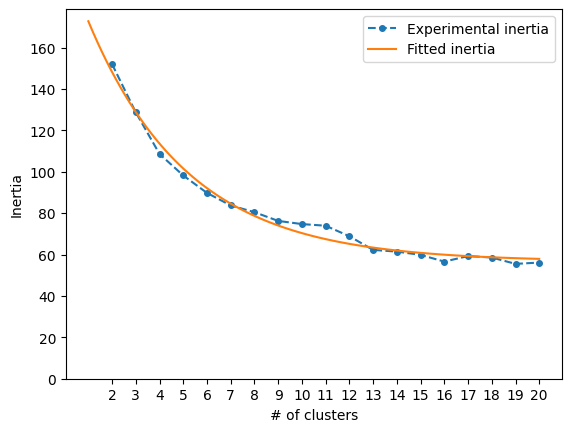

In [17]:
plt.plot(globalMetrics.index, globalMetrics["inertia"], label="Experimental inertia", ls="dashed", marker = "o", ms=4)

x = pd.Series(np.linspace(1,20,100))
plt.plot(x, x.apply(model_func, args=opt.tolist() ), label="Fitted inertia")

slope = deriv_func(10,*opt)
intercept = model_func(10, *opt)-10*slope

ystart = slope*1+intercept
yend = slope*17+intercept

# plt.plot([1,17], [ystart,yend], color="red", ls = "dashed", label="tg")

plt.xticks(globalMetrics.index, globalMetrics.index)
plt.ylim([0,None])

plt.xlabel("# of clusters")
plt.ylabel("Inertia")
plt.legend()
plt.savefig('figures/')

In [18]:
from src.plot_utils import gradientbars_sliced, truncate_colormap

In [19]:
blueMap  = truncate_colormap( plt.get_cmap("Blues"), minval=.2 )
orangeMap = truncate_colormap( plt.get_cmap("Oranges"), minval=.2 )

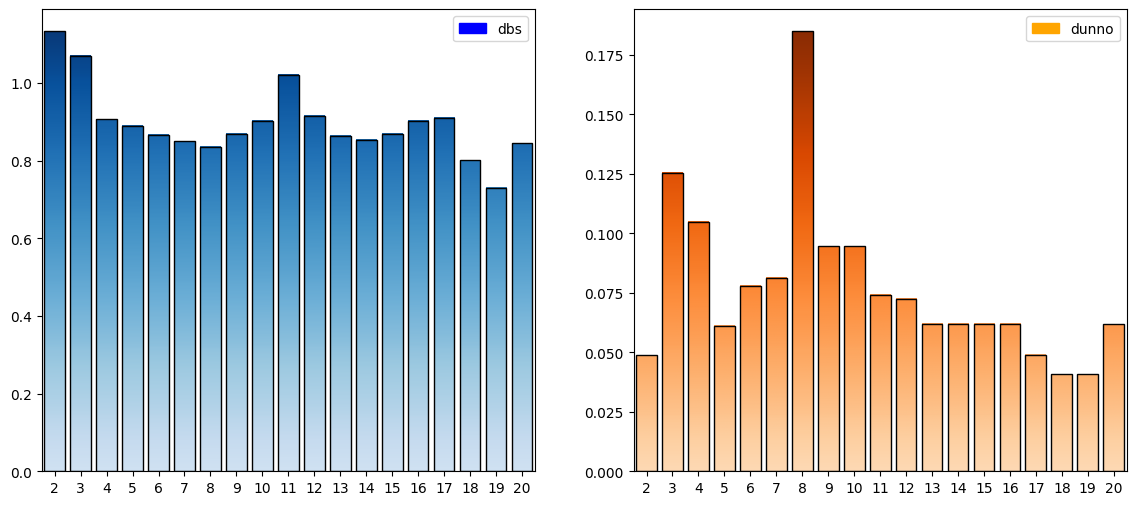

In [20]:
fig, plots = plt.subplots(ncols=2, figsize=(14,6), sharex=True)
mtrcs = ["dbs",
         "dunno"
         ]
clrs = [blueMap, orangeMap]
lgnds=["blue","orange"]

for plot, mtrc, clr, lgnd in zip(plots.flatten(), mtrcs, clrs, lgnds):
    bar = plot.bar(globalMetrics.index, globalMetrics[mtrc], label=mtrc, edgecolor="black")
    gradientbars_sliced(bar, clr)

    plot.set_xticks(globalMetrics.index)
    leg = plot.legend()
    leg.legend_handles[0].set_color(lgnd)
    plot.set_xlim([1.5, 20.5])

## Silhouette

In [21]:
greenMap = truncate_colormap( plt.get_cmap("Greens"), minval=.2 )

In [22]:
def plotBlob(df, ax):
    sortCluster = df.sort_values("cluster").reset_index()
    avg = sortCluster["silhouette"].mean()

    ticksList = []
    for shift,(iCluster, idxs) in enumerate(sortCluster.groupby("cluster").groups.items()):
        sortSil = sortCluster.loc[idxs].sort_values("silhouette", ascending=False)
        idxs+=shift
        pos = np.mean(idxs)
        name = f"cluster {int(iCluster)}"
        ticksList.append( (pos,name) )
        
        ax.fill_between(
            idxs,
            sortSil["silhouette"],
            alpha=0.7,
        )

    ax.axhline(avg, color="black", ls="dashed", label="Mean silhouette")
    ax.set_xticks(*zip(*ticksList), rotation=80)
    # ax.legend()
    # ax.show()

In [23]:
def plotSilhouette(df, ax):
    sortCluster = df.sort_values("cluster").reset_index()
    avg = sortCluster["silhouette"].mean()

    ticksList = []
    for shift,(iCluster, idxs) in enumerate(sortCluster.groupby("cluster").groups.items()):
        sortSil = sortCluster.loc[idxs].sort_values("silhouette", ascending=False)
        idxs+=shift
        pos = np.mean(idxs)
        name = f"cluster {int(iCluster)}"
        ticksList.append( (pos,name) )
        ax.bar(idxs, sortSil["silhouette"],)
        
        # if "new" in sortSil["base"].tolist():
        #     # print(sortSil)
        #     reset = sortSil.reset_index(drop=True)
        #     query = reset.query("base=='new'")
        #     idx  = idxs[query.index[0]]
        #     sil = query["silhouette"]
        #     ax.bar(idx, sil, color="black")

    ax.axhline(avg, color="black", ls="dashed", label="Mean silhouette")
    ax.set_xticks(*zip(*ticksList), rotation=80)
    # ax.legend()
    # ax.show()

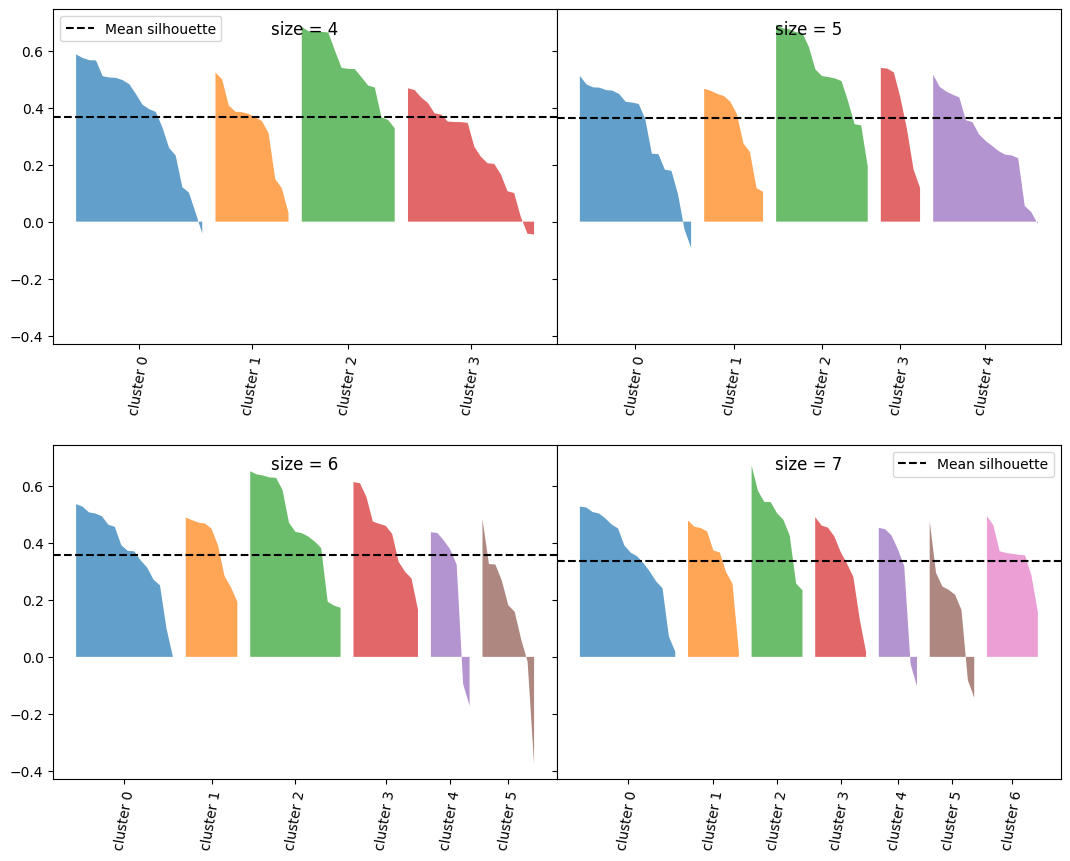

In [24]:
sizes  = [4,5,6,7]
fig, plots = plt.subplots(ncols=2, nrows=2, figsize=(13,10), gridspec_kw={"hspace":.3,"wspace":0}, sharey=True)

for size, plot in zip(sizes, plots.flatten()):
    plotBlob( dataloader.get_local_cluster('kmedoids', seed=0, size=size), plot)
    plot.set_title(f"size = {size}", y=.9)
    
# plot=plots[0,0]
# bar = plot.bar(globalMetrics.index, globalMetrics["silhouette"], edgecolor="black")
# gradientbars_sliced(bar, greenMap)

# plot.set_xticks(globalMetrics.index)
# plot.set_xlim([1.5, 20.5])

plots[0,0].legend(loc="upper left")
plots[1,1].legend(loc="upper right")

In [25]:
posColor = truncate_colormap( plt.get_cmap("Blues") )
negColor = truncate_colormap( plt.get_cmap("Reds"), minval=.2 )

Text(0, 0.5, 'Normalized Δ of Silhouette score')

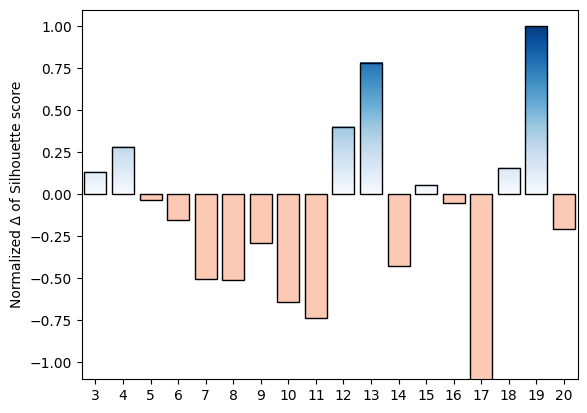

In [26]:
subDF =  globalMetrics["silhouette"].diff().iloc[1:]
subDF = subDF/subDF.max()
# subDF = subDF/globalMetrics["silhouette"].iloc[:-1]
posVals = subDF>0
negVals = subDF<0

bar = plt.bar(subDF[posVals].index, subDF[posVals], edgecolor="black")
gradientbars_sliced(bar, posColor)

bar = plt.bar(subDF[negVals].index, subDF[negVals], edgecolor="black")
gradientbars_sliced(bar, negColor)

plt.xticks(globalMetrics.index)
plt.xlim([2.5, 20.5])
plt.ylim(-1.1,1.1)
# plt.ylim(-.2,None)

plt.ylabel('Normalized Δ of Silhouette score')

5 is the optimal number of cluster to be formed (plus the outliers !).